### *classification* 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, log_loss

In [2]:
# Function to calculate confusion matrix
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

In [3]:
# Function to calculate accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

In [4]:
# Function to calculate precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    return TP / (TP + FP) if (TP + FP) > 0 else 0

In [5]:
# Function to calculate recall
def recall(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    return TP / (TP + FN) if (TP + FN) > 0 else 0


In [6]:
# Function to calculate F1 score
def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r) if (p + r) > 0 else 0


In [7]:
# Function to calculate specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    return TN / (TN + FP) if (TN + FP) > 0 else 0

In [8]:
# Function to calculate Matthews Correlation Coefficient (MCC)
def mcc(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    numerator = (TP * TN) - (FP * FN)
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return numerator / denominator if denominator > 0 else 0

In [9]:
# Function to evaluate all metrics
def evaluate_metrics(y_true, y_pred, y_prob):
    print("Confusion Matrix: TP, TN, FP, FN")
    print(confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy(y_true, y_pred))
    print("Precision:", precision(y_true, y_pred))
    print("Recall:", recall(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Specificity:", specificity(y_true, y_pred))
    print("Cross Entropy Loss:", log_loss(y_true, y_prob))
    print("MCC:", mcc(y_true, y_pred))

In [10]:
# Function to plot ROC curve and print AUC
def plot_roc_and_auc(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

Confusion Matrix: TP, TN, FP, FN
(np.int64(3), np.int64(4), np.int64(1), np.int64(2))
Accuracy: 0.7
Precision: 0.75
Recall: 0.6
F1 Score: 0.6666666666666665
Specificity: 0.8
Cross Entropy Loss: 0.581958147280769
MCC: 0.408248290463863


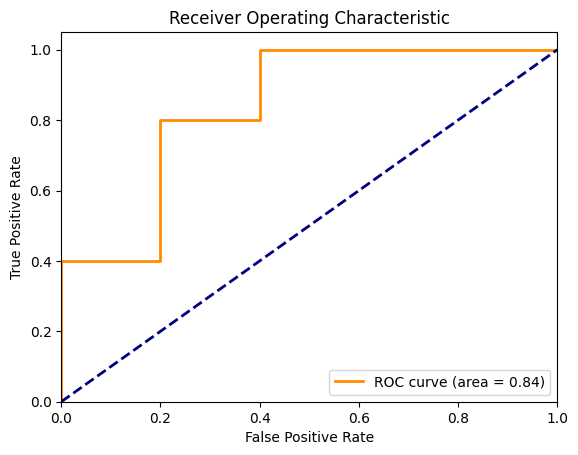

In [11]:
# Example usage
y_true = np.array([0, 1, 0, 1, 0, 1, 0, 1, 1, 0])
y_pred = np.array([0, 1, 0, 0, 0, 1, 1, 1, 0, 0])
y_prob = np.array([0.17, 0.39, 0.29, 0.38, 0.12, 0.87, 0.79, 0.85, 0.25, 0.005])

evaluate_metrics(y_true, y_pred, y_prob)
plot_roc_and_auc(y_true, y_prob)

### Multi-class Classification

In [12]:
from sklearn.preprocessing import label_binarize
from scipy.special import softmax

##### Functions for calculating metrics

In [14]:
def confusion_matrix(y_true, y_pred, classes):
    n_classes = len(classes)
    cm = np.zeros((n_classes, n_classes), int)
    for i, c1 in enumerate(classes):
        for j, c2 in enumerate(classes):
            cm[i, j] = np.sum((y_true == c1) & (y_pred == c2))
    return cm

In [15]:
def calculate_metrics(cm):
    precision = np.diag(cm) / np.sum(cm, axis=0, where=(np.sum(cm, axis=0) != 0))
    recall = np.diag(cm) / np.sum(cm, axis=1, where=(np.sum(cm, axis=1) != 0))
    f1 = 2 * (precision * recall) / (precision + recall + (precision + recall == 0))
    specificity = np.sum(cm, axis=1) - np.diag(cm) / (np.sum(cm) - np.sum(cm, axis=0))
    return precision, recall, f1, specificity


In [16]:
def aggregate_metrics(cm, average='macro'):
    precision, recall, f1, _ = calculate_metrics(cm)
    if average == 'macro':
        return precision.mean(), recall.mean(), f1.mean()
    elif average == 'micro':
        total_true_positives = np.sum(np.diag(cm))
        total_predicted = np.sum(cm, axis=0)
        total_actual = np.sum(cm, axis=1)
        micro_precision = total_true_positives / total_predicted.sum()
        micro_recall = total_true_positives / total_actual.sum()
        micro_f1 = 2 * (micro_precision * micro_recall) / (micro_precision + micro_recall)
        return micro_precision, micro_recall, micro_f1
    elif average == 'weighted':
        weights = np.sum(cm, axis=1) / np.sum(cm)
        weighted_precision = np.average(precision, weights=weights)
        weighted_recall = np.average(recall, weights=weights)
        weighted_f1 = np.average(f1, weights=weights)
        return weighted_precision, weighted_recall, weighted_f1

#### Evaluation function

In [17]:
def evaluate_all(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, classes)
    accuracy = np.trace(cm) / np.sum(cm)
    precision, recall, f1, specificity = calculate_metrics(cm)
    macro_precision, macro_recall, macro_f1 = aggregate_metrics(cm, 'macro')
    micro_precision, micro_recall, micro_f1 = aggregate_metrics(cm, 'micro')
    weighted_precision, weighted_recall, weighted_f1 = aggregate_metrics(cm, 'weighted')

    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {accuracy:.2f}")
    print("Precision per class:", precision)
    print("Recall per class:", recall)
    print("F1 Score per class:", f1)
    print("Specificity per class:", specificity)
    print(f"Macro Average: Precision: {macro_precision:.2f}, Recall: {macro_recall:.2f}, F1: {macro_f1:.2f}")
    print(f"Micro Average: Precision: {micro_precision:.2f}, Recall: {micro_recall:.2f}, F1: {micro_f1:.2f}")
    print(f"Weighted Average: Precision: {weighted_precision:.2f}, Recall: {weighted_recall:.2f}, F1: {weighted_f1:.2f}")

    return cm, precision, recall, f1, specificity

In [18]:
# Example Data
classes = np.array([0, 1, 2])  # Class labels
y_true = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 1])
y_pred = np.array([0, 1, 0, 0, 1, 1, 0, 1, 2, 2])
y_prob = softmax(np.random.rand(10, 3), axis=1)  # Random probabilities for example

In [19]:
# Evaluate metrics
cm, precision, recall, f1, specificity = evaluate_all(y_true, y_pred, classes)

Confusion Matrix:
 [[3 0 0]
 [0 3 1]
 [1 1 1]]
Accuracy: 0.70
Precision per class: [0.75 0.75 0.5 ]
Recall per class: [1.         0.75       0.33333333]
F1 Score per class: [0.85714286 0.75       0.4       ]
Specificity per class: [2.5   3.5   2.875]
Macro Average: Precision: 0.67, Recall: 0.69, F1: 0.67
Micro Average: Precision: 0.70, Recall: 0.70, F1: 0.70
Weighted Average: Precision: 0.68, Recall: 0.70, F1: 0.68


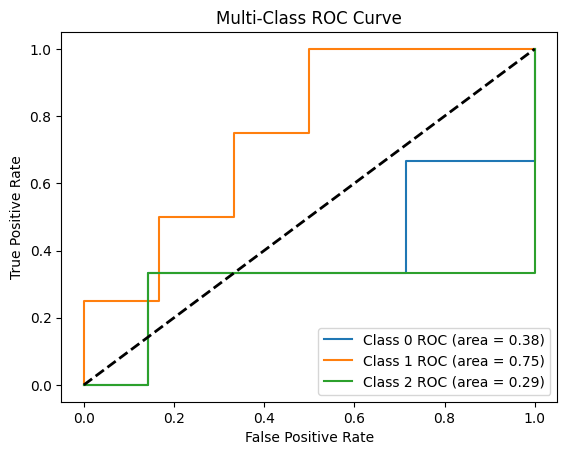

In [20]:
# Plotting ROC Curves for Multi-Class
def plot_roc_curves(y_true, y_prob, classes):
    y_true = label_binarize(y_true, classes=classes)
    n_classes = y_true.shape[1]
    
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} ROC (area = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

plot_roc_curves(y_true, y_prob, classes)